# EDA — `satisfaction_surveys`: what do surveys add to the complaint-workflow hypothesis?

**Where we left off (`complaints.ipynb`).** The complaint file has a satisfaction rating for only 3.7% of
complaints, no free text, and shows no relation between time-to-resolution, compensation and satisfaction.
The survey dataset is much larger and has scores, question answers, comments and sentiment.

**Questions.**

1. Is the survey data internally consistent and usable (scales, NPS, sentiment, comments)?
2. What drives the scores (channel, agent, time, response time, question answers, customer)?
3. What do customers say (themes in the comments), and does it point at speed or at resolution quality?
4. Can surveys be linked to complaints, and does satisfaction relate to complaint resolution time or compensation?
5. Does it change the case for an agentic complaint workflow?

Scope: all 1,097 daily files (2023-06-17 to 2026-06-17), descriptive only, no model. Nothing is imputed or
invented. Loaded whole (44 MB on disk); identifiers that are not needed later are dropped and process memory is measured.

## 1. Setup and load

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from IPython.display import display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
SURVEYS_ROOT = REPO_ROOT / "data" / "satisfaction_surveys"
COMPLAINTS_ROOT = REPO_ROOT / "data" / "complaints"
DATA_DIRECTORY = REPO_ROOT / "data" / "data"

BAR_COLOR = "#2E6DB4"
MUTED_COLOR = "#6B7280"
CATEGORY_COLUMNS = ["survey_type", "send_channel", "nps_category", "comment_sentiment", "question_1_text",
                    "question_2_text", "question_3_text", "open_comments", "agent_id"]


def current_memory_mb() -> float:
    """Measures the resident memory of this notebook's process.

    Exists to show the analysis stays small on a machine with limited free RAM.

    Args:
        None.

    Returns:
        float: resident set size in megabytes.
    """
    return psutil.Process().memory_info().rss / 1e6


memory_start_mb = current_memory_mb()
partition_files = sorted(SURVEYS_ROOT.glob("year=*/month=*/day=*/satisfaction_surveys_*.csv"))
surveys = pd.concat((pd.read_csv(path) for path in partition_files), ignore_index=True)
surveys["survey_date"] = pd.to_datetime(surveys["survey_date"])
surveys["process_date"] = pd.to_datetime(surveys["process_date"])

identifier_checks = pd.Series({
    "duplicate survey_id": surveys["survey_id"].duplicated().sum(),
    "duplicate interaction_id": surveys["interaction_id"].duplicated().sum(),
})
surveys = surveys.drop(columns=["survey_id", "interaction_id"])
surveys[CATEGORY_COLUMNS] = surveys[CATEGORY_COLUMNS].astype("category")

display(pd.Series({
    "daily files": len(partition_files),
    "surveys": len(surveys),
    "distinct customers": surveys["customer_id"].nunique(),
    "distinct agents": surveys["agent_id"].nunique(),
    "first / last survey_date": f"{surveys['survey_date'].min()} / {surveys['survey_date'].max()}",
    "duplicate survey_id / interaction_id": f"{identifier_checks['duplicate survey_id']} / {identifier_checks['duplicate interaction_id']}",
    "process memory before / after loading, MB": f"{memory_start_mb:,.0f} / {current_memory_mb():,.0f}",
}, name="value").to_frame())

,value
daily files,1097
surveys,212759
distinct customers,113640
distinct agents,1090
first / last survey_date,2023-06-17 09:29:20 / 2026-06-19 06:54:58
duplicate survey_id / interaction_id,0 / 0
"process memory before / after loading, MB",129 / 260


## 2. Structure and data quality

In [2]:
schema = pd.DataFrame({
    "dtype": surveys.dtypes.astype(str),
    "missing_pct": surveys.isna().mean() * 100,
    "distinct": surveys.nunique(),
})
display(schema)
display(surveys.groupby("survey_type", observed=True)["main_score"].agg(["count", "min", "max", "mean"]))
display(pd.crosstab(surveys["main_score"], surveys["survey_type"]))

,dtype,missing_pct,distinct
survey_date,datetime64[us],0.00,212505
process_date,datetime64[us],0.00,1097
customer_id,str,0.00,113640
agent_id,category,0.00,1090
survey_type,category,0.00,3
send_channel,category,0.00,5
main_score,int64,0.00,7
nps_category,category,71.61,2
question_1_text,category,42.99,3
question_1_response,float64,42.95,5


,count,min,max,mean
survey_type,,,,
CES,21235,1,4,2.77
CSAT,127856,1,4,2.77
NPS,63668,2,7,5.31


survey_type,CES,CSAT,NPS
main_score,,,
1,737,4422,0
2,5894,35646,4858
3,12150,73313,4900
4,2454,14475,4876
5,0,0,16475
6,0,0,16329
7,0,0,16230


There are three survey types with **different scales**: `CSAT` and `CES` use 1-4, and `NPS` uses **2-7**.
Scores are therefore not comparable across types and each is analysed on its own. A 2-7 scale is not a real NPS
scale (0-10), which matters below.

In [3]:
nps = surveys[surveys["survey_type"] == "NPS"]
display(pd.crosstab(nps["main_score"], nps["nps_category"].astype(str)))
category_shares = nps["nps_category"].astype(str).value_counts(normalize=True) * 100
display(category_shares.to_frame("% of categorised NPS surveys"))
display(pd.Series({
    "NPS as %promoters - %detractors (of categorised surveys)":
        -(nps["nps_category"] == "Detractor").sum() / nps["nps_category"].notna().sum() * 100,
    "promoters in the file": (nps["nps_category"] == "Promoter").sum(),
}, name="value").to_frame())
display(pd.crosstab(surveys["main_score"], surveys["comment_sentiment"].astype(str)))
display(pd.Series({
    "surveys with a sentiment but no comment": (surveys["comment_sentiment"].notna() & surveys["open_comments"].isna()).sum(),
    "surveys with a comment but no sentiment": (surveys["comment_sentiment"].isna() & surveys["open_comments"].notna()).sum(),
}, name="count").to_frame())

nps_category,Detractor,Passive
main_score,,
2,4621,0
3,4630,0
4,4608,0
5,15651,0
6,15497,0
7,0,15387


,% of categorised NPS surveys
nps_category,
Detractor,74.52
Passive,25.48


,value
NPS as %promoters - %detractors (of categorised surveys),-74.52
promoters in the file,0.00


comment_sentiment,Negative,Neutral,Positive
main_score,,,
1,2485,0,0
2,22045,0,0
3,42999,0,0
4,0,3535,6954
5,0,7840,0
6,0,7716,0
7,0,7683,0


,count
surveys with a sentiment but no comment,5079
surveys with a comment but no sentiment,5018


**NPS.** Categories follow the score (2-6 Detractor, 7 Passive, some missing), but with a scale that stops
at 7 **no customer can be a Promoter**. The file's implied NPS is -74.5 (74.5% Detractors of the
categorised surveys), an artefact of the scale, not a customer signal. It should not be quoted as NPS.

**Sentiment.** `comment_sentiment` is a function of the score band (1-3 Negative, 4-7 Neutral, and Positive only
on the top CSAT/CES score) and is also filled on rows that have no comment (counts above).

In [4]:
display(surveys.groupby("survey_type", observed=True)[["question_1_response", "question_2_response", "question_3_response"]]
        .agg(lambda s: s.notna().mean() * 100))
display(surveys.groupby("survey_type", observed=True)["open_comments"].agg(lambda s: s.notna().mean() * 100).to_frame("% with a comment"))
display(surveys.groupby("main_score")["open_comments"].agg(lambda s: s.notna().mean() * 100).to_frame("% with a comment, by score"))
for column in ["question_1_response", "question_2_response", "question_3_response"]:
    display(surveys[column].value_counts(normalize=True).sort_index().mul(100).to_frame(f"{column} (%)"))
display(surveys[["response_time_hours", "campaign_response_rate"]].describe())

,question_1_response,question_2_response,question_3_response
survey_type,,,
CES,57.03,38.24,18.77
CSAT,57.16,38.33,18.81
NPS,56.82,38.27,18.96


,% with a comment
survey_type,
CES,47.51
CSAT,47.65
NPS,47.40


,"% with a comment, by score"
main_score,
1,47.99
2,47.56
3,47.51
4,48.26
5,47.34
6,47.19
7,47.38


,question_1_response (%)
question_1_response,
1.00,19.82
2.00,19.95
3.00,20.03
4.00,19.95
5.00,20.25


,question_2_response (%)
question_2_response,
1.00,19.69
2.00,19.90
3.00,20.33
4.00,20.21
5.00,19.87


,question_3_response (%)
question_3_response,
1.00,20.39
2.00,19.83
3.00,20.02
4.00,20.19
5.00,19.56


,response_time_hours,campaign_response_rate
count,"212,759.00","180,722.00"
mean,18.47,29.96
std,7.49,8.66
min,1.01,15.00
25%,12.73,22.45
50%,18.46,29.95
75%,24.23,37.46
max,35.97,45.00


The three follow-up questions are answered on a 1-5 scale, **uniformly** (20% per value), at the same rate for every
survey type and every main score. A comment is written on ~47% of surveys whatever the score. `response_time_hours` is
1-36 h and `campaign_response_rate` 15-45% (15% missing), both uniform.

### Timestamps

In [5]:
offset_days = (surveys["survey_date"].dt.normalize() - surveys["process_date"]).dt.days
send_time = surveys["survey_date"] - pd.to_timedelta(surveys["response_time_hours"], unit="h")
display(offset_days.value_counts().sort_index().to_frame("surveys").rename_axis("survey_date - process_date (days)"))
display(pd.Series({
    "share where (survey_date - response_time_hours).date == process_date": (send_time.dt.normalize() == surveys["process_date"]).mean() * 100,
    "latest process_date": surveys["process_date"].max(),
    "latest survey_date": surveys["survey_date"].max(),
}, name="value").to_frame())

,surveys
survey_date - process_date (days),
0,43667
1,156851
2,12241


,value
share where (survey_date - response_time_hours).date == process_date,86.21
latest process_date,2026-06-17 00:00:00
latest survey_date,2026-06-19 06:54:58


`process_date` is 0-2 days before the calendar date of `survey_date`: it looks like the **send day**, with
`survey_date` = send time + `response_time_hours` (true for ~86% of rows). Partitions follow `process_date`. Response
dates therefore extend up to two days past the last partition (2026-06-17).

## 3. Volume and mix

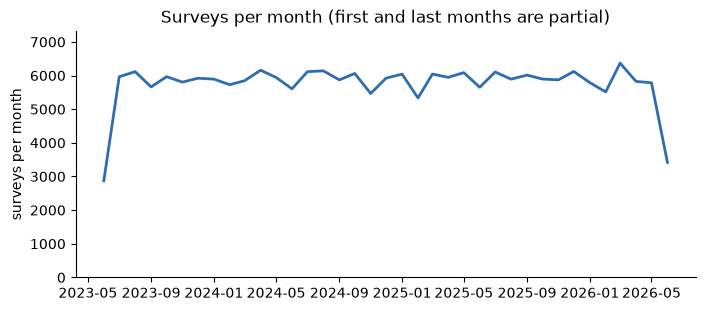

,surveys per full month
count,35.00
mean,"5,899.23"
std,216.35
min,"5,334.00"
25%,"5,797.00"
50%,"5,921.00"
75%,"6,052.00"
max,"6,369.00"


,survey_type (%)
survey_type,
CSAT,60.09
NPS,29.92
CES,9.98


,send_channel (%)
send_channel,
Email,39.89
SMS,29.99
App,20.02
IVR,5.09
Web,5.01


survey_type,CES,CSAT,NPS
send_channel,,,
App,10.07,60.06,29.87
Email,9.95,60.23,29.82
IVR,10.05,60.13,29.82
SMS,9.89,59.91,30.21
Web,10.35,60.23,29.43


In [6]:
monthly = surveys.groupby(surveys["process_date"].dt.to_period("M")).size()
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(monthly.index.to_timestamp(), monthly.values, color=BAR_COLOR, linewidth=2)
ax.set_ylim(0, monthly.max() * 1.15)
ax.set_ylabel("surveys per month")
ax.set_title("Surveys per month (first and last months are partial)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()
display(monthly.iloc[1:-1].describe().to_frame("surveys per full month"))
for column in ["survey_type", "send_channel"]:
    display((surveys[column].value_counts(normalize=True) * 100).to_frame(f"{column} (%)"))
display(pd.crosstab(surveys["send_channel"], surveys["survey_type"], normalize="index").mul(100))

## 4. What drives the scores?

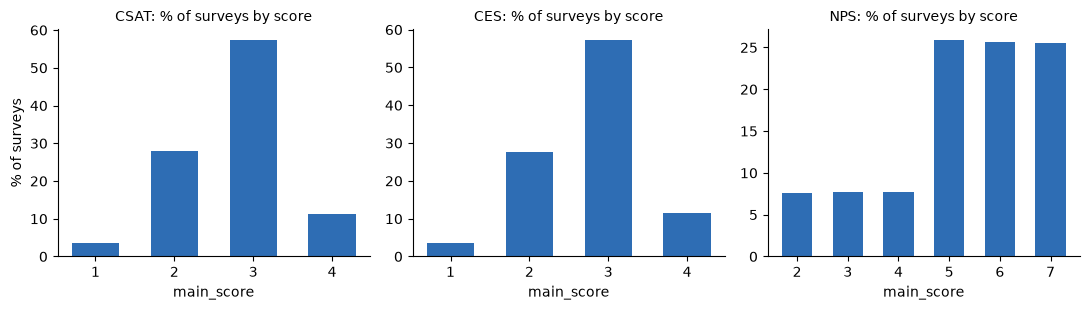

In [7]:
score_distribution = pd.crosstab(surveys["main_score"], surveys["survey_type"], normalize="columns") * 100
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for axis, survey_type in zip(axes, ["CSAT", "CES", "NPS"]):
    shares = score_distribution[survey_type][score_distribution[survey_type] > 0]
    axis.bar(shares.index.astype(str), shares.values, color=BAR_COLOR, width=0.6)
    axis.set_title(f"{survey_type}: % of surveys by score", fontsize=10)
    axis.set_xlabel("main_score")
    axis.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("% of surveys")
plt.tight_layout()
plt.show()

In [8]:
def mean_with_interval(frame: pd.DataFrame, group: str, value: str = "main_score") -> pd.DataFrame:
    """Summarises a score by group with a 95% half-width for the mean.

    Exists so differences between groups can be judged against their noise.

    Args:
        frame: Survey rows.
        group: Column to group by.
        value: Numeric column to summarise.

    Returns:
        pd.DataFrame: surveys, mean and 95% half-width of the mean per group.
    """
    grouped = frame.groupby(group, observed=True)[value].agg(surveys="size", mean="mean", std="std")
    grouped["ci"] = 1.96 * grouped["std"] / grouped["surveys"] ** 0.5
    return grouped.drop(columns="std")


csat = surveys[surveys["survey_type"] == "CSAT"]
nps_surveys = surveys[surveys["survey_type"] == "NPS"]
for survey_type, frame in {"CSAT (1-4)": csat, "NPS (2-7)": nps_surveys}.items():
    print(survey_type)
    display(mean_with_interval(frame, "send_channel"))

CSAT (1-4)


,surveys,mean,ci
send_channel,,,
App,25583,2.77,0.01
Email,51123,2.77,0.01
IVR,6516,2.75,0.02
SMS,38220,2.77,0.01
Web,6414,2.75,0.02


NPS (2-7)


,surveys,mean,ci
send_channel,,,
App,12722,5.30,0.03
Email,25310,5.30,0.02
IVR,3231,5.33,0.05
SMS,19271,5.31,0.02
Web,3134,5.30,0.05


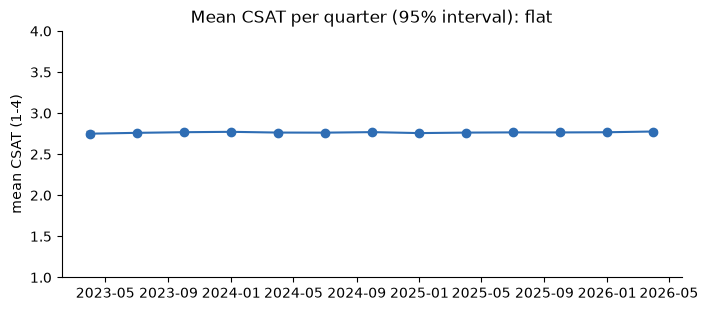

,surveys,mean,ci
quarter,,,
2023Q2,1734,2.75,0.03
2023Q3,10703,2.76,0.01
2023Q4,10652,2.77,0.01
2024Q1,10562,2.77,0.01
2024Q2,10657,2.76,0.01
2024Q3,10921,2.76,0.01
2024Q4,10497,2.77,0.01
2025Q1,10570,2.76,0.01
2025Q2,10624,2.76,0.01


In [9]:
csat_by_quarter = mean_with_interval(csat.assign(quarter=csat["process_date"].dt.to_period("Q")), "quarter")
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.errorbar(csat_by_quarter.index.to_timestamp(), csat_by_quarter["mean"], yerr=csat_by_quarter["ci"],
            fmt="o-", color=BAR_COLOR, ecolor=MUTED_COLOR, capsize=3)
ax.set_ylim(1, 4)
ax.set_ylabel("mean CSAT (1-4)")
ax.set_title("Mean CSAT per quarter (95% interval): flat")
ax.spines[["top", "right"]].set_visible(False)
plt.show()
display(csat_by_quarter)

In [10]:
def agent_spread_versus_chance(frame: pd.DataFrame, minimum_surveys: int) -> pd.Series:
    """Compares the spread of agents' mean scores with what identical agents would produce.

    Exists to test whether agents really differ in the satisfaction they generate.

    Args:
        frame: Surveys of a single survey type.
        minimum_surveys: Agents with fewer surveys are left out.

    Returns:
        pd.Series: agents used, observed spread of agent means and the spread expected from chance.
    """
    per_agent = frame.groupby("agent_id", observed=True)["main_score"].agg(["size", "mean"])
    per_agent = per_agent[per_agent["size"] >= minimum_surveys]
    return pd.Series({
        "agents used": len(per_agent),
        "std of agents' mean score (observed)": per_agent["mean"].std(),
        "std expected if agents were identical": ((frame["main_score"].var() / per_agent["size"]).mean()) ** 0.5,
    })


display(pd.DataFrame({
    "CSAT": agent_spread_versus_chance(csat, 30),
    "NPS": agent_spread_versus_chance(nps_surveys, 30),
}))
display(surveys.groupby("agent_id", observed=True).size().describe().to_frame("surveys per agent"))

customers = pd.read_csv(DATA_DIRECTORY / "customers.csv", usecols=["customer_id", "segment", "country", "customer_status"])
csat_customers = csat.merge(customers, on="customer_id", how="left")
display(pd.Series({"survey customer_ids present in customers.csv (%)": surveys["customer_id"].isin(customers["customer_id"]).mean() * 100}, name="value").to_frame())
for column in ["segment", "country", "customer_status"]:
    display(mean_with_interval(csat_customers, column))

,CSAT,NPS
agents used,"1,090.00","1,090.00"
std of agents' mean score (observed),0.06,0.19
std expected if agents were identical,0.06,0.20


,surveys per agent
count,"1,090.00"
mean,195.19
std,13.79
min,156.00
25%,186.00
50%,194.00
75%,204.00
max,243.00


,value
survey customer_ids present in customers.csv (%),100.00


,surveys,mean,ci
segment,,,
Basic,76125,2.77,0.00
Plus,32375,2.76,0.01
Premium,12886,2.76,0.01
Student,6470,2.77,0.02


,surveys,mean,ci
country,,,
Argentina,25620,2.77,0.01
Colombia,38411,2.77,0.01
México,63825,2.76,0.01


,surveys,mean,ci
customer_status,,,
Active,108711,2.76,0.00
Closed,2608,2.75,0.03
Inactive,12696,2.77,0.01
Suspended,3841,2.77,0.02


In [11]:
correlation_rows = []
for survey_type, frame in surveys.groupby("survey_type", observed=True):
    for column in ["question_1_response", "question_2_response", "question_3_response", "response_time_hours", "campaign_response_rate"]:
        pair = frame[["main_score", column]].dropna()
        correlation_rows.append({
            "survey_type": survey_type, "variable": column, "surveys": len(pair),
            "spearman_with_main_score": pair["main_score"].rank().corr(pair[column].rank()),
        })
display(pd.DataFrame(correlation_rows).pivot(index="variable", columns="survey_type", values="spearman_with_main_score"))

survey_type,CES,CSAT,NPS
variable,,,
campaign_response_rate,-0.01,0.00,-0.01
question_1_response,-0.00,0.01,-0.01
question_2_response,-0.01,0.00,0.00
question_3_response,-0.01,-0.01,-0.00
response_time_hours,0.00,-0.00,-0.00


**Nothing moves the score.** CSAT is ~2.77 (out of 4) in every channel, every quarter (2.75-2.78), every customer
segment, country and status. The spread of agents' average scores equals what identical agents produce by chance, so
there is no evidence of better or worse agents. The follow-up question answers, `response_time_hours` and
`campaign_response_rate` have ~0 rank correlation with the main score. In particular, **a question that
asks "was the waiting time acceptable?" is unrelated to the overall score**, and so is how long the customer took to answer.

## 5. What customers say: comments and themes

In [12]:
NEGATIVE_COMMENT_THEMES = {
    "Tardaron mucho en atenderme.": "waiting time",
    "Tuve que esperar demasiado tiempo.": "waiting time",
    "No resolvieron mi problema completamente.": "problem not resolved",
    "No estoy satisfecho con la solución.": "problem not resolved",
    "El agente no fue muy claro en sus explicaciones.": "unclear explanation",
}
commented = surveys.dropna(subset=["open_comments"]).copy()
commented["open_comments"] = commented["open_comments"].astype(str)
display(pd.crosstab(commented["open_comments"], commented["comment_sentiment"].astype(str)))

comment_sentiment,Negative,Neutral,Positive
open_comments,,,
Aceptable.,0,8361,0
"Buena experiencia, gracias.",0,0,1278
El agente fue muy profesional y eficiente.,0,0,1324
El agente no fue muy claro en sus explicaciones.,12705,0,0
El servicio estuvo bien.,0,8516,0
"Excelente atención, muy amable el agente.",0,0,1321
Muy satisfecho con el servicio.,0,0,1346
No estoy satisfecho con la solución.,12793,0,0
No resolvieron mi problema completamente.,12866,0,0


,value
surveys with a comment,101196
of which Negative,64107
Negative comments not mapped to a theme,0


,% of negative comments,comments
theme,,
waiting time,40.16,25743
problem not resolved,40.03,25659
unclear explanation,19.82,12705


survey_type,CES,CSAT,NPS
theme,,,
problem not resolved,39.42,40.19,39.26
unclear explanation,20.16,19.76,19.84
waiting time,40.43,40.05,40.90


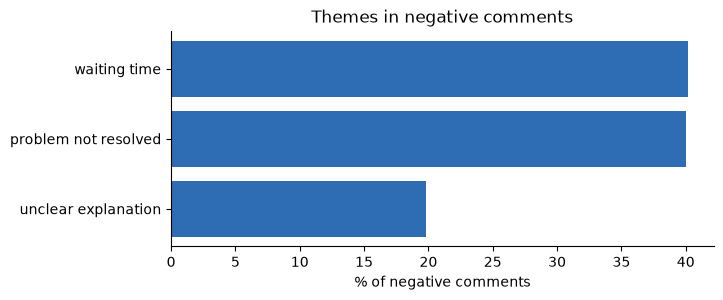

,size,mean
open_comments,,
Aceptable.,3376,2.99
"Buena experiencia, gracias.",529,3.03
El agente fue muy profesional y eficiente.,526,2.96
El agente no fue muy claro en sus explicaciones.,5111,3.04
El servicio estuvo bien.,3389,3.00
"Excelente atención, muy amable el agente.",534,3.01
Muy satisfecho con el servicio.,529,3.01
No estoy satisfecho con la solución.,5152,3.00
No resolvieron mi problema completamente.,5326,3.00


In [13]:
negative = commented[commented["comment_sentiment"] == "Negative"].copy()
negative["theme"] = negative["open_comments"].map(NEGATIVE_COMMENT_THEMES)
theme_shares = negative["theme"].value_counts(dropna=False)
display(pd.Series({
    "surveys with a comment": len(commented),
    "  of which Negative": len(negative),
    "  Negative comments not mapped to a theme": negative["theme"].isna().sum(),
}, name="value").to_frame())
display((theme_shares / len(negative) * 100).to_frame("% of negative comments").join(theme_shares.to_frame("comments")))
display(pd.crosstab(negative["theme"], negative["survey_type"], normalize="columns").mul(100))

fig, ax = plt.subplots(figsize=(7, 2.8))
ordered = (theme_shares / len(negative) * 100).sort_values()
ax.barh(ordered.index.astype(str), ordered.values, color=BAR_COLOR)
ax.set_xlabel("% of negative comments")
ax.set_title("Themes in negative comments")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

consistency = commented.dropna(subset=["question_2_response"]).groupby("open_comments")["question_2_response"].agg(["size", "mean"])
display(consistency)

There are only **13 distinct comments** (five negative, three neutral, five positive), so this is not real free text.
Read as themes, negative comments split into **waiting time (40%)**, **problem not resolved (40%)** and **unclear
explanation (20%)**, i.e. about equal weight on "slow" and "not resolved". But the themes are not consistent with the
structured answers: customers whose comment says they waited too long rate "was the waiting time acceptable?" **3.0 out of 5, the
same as customers who wrote "excellent attention"**. The comments carry no independent information beyond the score band.

## 6. Link to complaints

The surveys are per **interaction** (`interaction_id`), while complaints record their originating interaction
in `origin_interaction_id`, which is **empty for every complaint**. There is therefore no direct key. We test the
indirect links the data allows: the customer, the agent, and the time proximity.

In [14]:
complaints = pd.concat(
    (pd.read_csv(path, usecols=["complaint_id", "customer_id", "creation_date", "resolution_date", "resolution_days",
                                "compensation_granted", "assigned_agent_id", "status", "resolution_satisfaction"])
     for path in sorted(COMPLAINTS_ROOT.glob("year=*/month=*/day=*/complaints_*.csv"))),
    ignore_index=True,
)
for column in ["creation_date", "resolution_date"]:
    complaints[column] = pd.to_datetime(complaints[column])

complaint_customers = set(complaints["customer_id"])
surveys["customer_has_complaint"] = surveys["customer_id"].isin(complaint_customers)
survey_agents, complaint_agents = set(surveys["agent_id"].astype(str)), set(complaints["assigned_agent_id"].dropna())
display(pd.Series({
    "survey customers": surveys["customer_id"].nunique(),
    "  of which also file complaints": surveys.loc[surveys["customer_has_complaint"], "customer_id"].nunique(),
    "  as % (complaint customers are 36% of the customer base)": surveys.loc[surveys["customer_has_complaint"], "customer_id"].nunique() / surveys["customer_id"].nunique() * 100,
    "survey agents also present as complaint agents": len(survey_agents & complaint_agents),
    "survey agents": len(survey_agents),
    "complaint agents": len(complaint_agents),
}, name="value").to_frame())

csat = surveys[surveys["survey_type"] == "CSAT"]
display(mean_with_interval(csat, "customer_has_complaint"))
display(mean_with_interval(surveys[surveys["survey_type"] == "NPS"], "customer_has_complaint"))

,value
survey customers,"113,640.00"
of which also file complaints,"41,059.00"
as % (complaint customers are 36% of the customer base),36.13
survey agents also present as complaint agents,"1,090.00"
survey agents,"1,090.00"
complaint agents,"1,200.00"


,surveys,mean,ci
customer_has_complaint,,,
False,81536,2.77,0.00
True,46320,2.76,0.01


,surveys,mean,ci
customer_has_complaint,,,
False,40636,5.30,0.01
True,23032,5.32,0.02


In [15]:
pairs = csat[["customer_id", "agent_id", "survey_date", "main_score"]].merge(
    complaints, on="customer_id", how="inner"
)
pairs["days_after_creation"] = (pairs["survey_date"] - pairs["creation_date"]).dt.total_seconds() / 86400
near = pairs[(pairs["days_after_creation"] >= 0) & (pairs["days_after_creation"] <= 30)].copy()
near["same_agent"] = near["agent_id"].astype(str) == near["assigned_agent_id"]

display(pd.Series({
    "CSAT survey / complaint pairs of the same customer": len(pairs),
    "  surveys within 30 days after the complaint was created": len(near),
    "  same agent handled both (%)": near["same_agent"].mean() * 100,
    "  same agent expected by chance (%, 1 / agents)": 100 / len(complaint_agents),
}, name="value").to_frame())

near["has_compensation"] = near["compensation_granted"].notna()
near["resolved"] = near["resolution_days"].notna()
near["resolution_band"] = pd.cut(near["resolution_days"], [0, 10, 20, 30])
display(mean_with_interval(near, "has_compensation"))
display(mean_with_interval(near, "resolved"))
display(mean_with_interval(near.dropna(subset=["resolution_days"]), "resolution_band"))

,value
CSAT survey / complaint pairs of the same customer,"57,416.00"
surveys within 30 days after the complaint was created,"1,622.00"
same agent handled both (%),0.12
"same agent expected by chance (%, 1 / agents)",0.08


,surveys,mean,ci
has_compensation,,,
False,1504,2.76,0.03
True,118,2.75,0.12


,surveys,mean,ci
resolved,,,
False,1253,2.76,0.04
True,369,2.74,0.07


,surveys,mean,ci
resolution_band,,,
"(0, 10]",119,2.74,0.11
"(10, 20]",118,2.66,0.13
"(20, 30]",132,2.81,0.12


In [16]:
customer_view = (
    csat.groupby("customer_id")["main_score"].mean().rename("mean_csat").reset_index()
    .merge(
        complaints.groupby("customer_id").agg(
            complaints=("complaint_id", "size"),
            any_compensation=("compensation_granted", lambda s: s.notna().any()),
            mean_resolution_days=("resolution_days", "mean"),
        ).reset_index(),
        on="customer_id",
    )
)
display(mean_with_interval(customer_view, "any_compensation", "mean_csat"))
with_resolution = customer_view.dropna(subset=["mean_resolution_days"])
display(pd.Series({
    "customers with CSAT and a resolved complaint": len(with_resolution),
    "Spearman: mean resolution days vs mean CSAT": with_resolution["mean_resolution_days"].rank().corr(with_resolution["mean_csat"].rank()),
    "Spearman: number of complaints vs mean CSAT": customer_view["complaints"].rank().corr(customer_view["mean_csat"].rank()),
}, name="value").to_frame())

agent_service = pd.concat([
    csat.groupby("agent_id", observed=True)["main_score"].mean().rename("mean_csat"),
    complaints.dropna(subset=["resolution_days"]).groupby("assigned_agent_id")["resolution_days"].agg(["size", "mean"])
    .rename(columns={"size": "resolved_cases", "mean": "mean_resolution_days"}),
], axis=1, join="inner")
agent_service = agent_service[agent_service["resolved_cases"] >= 5]
display(pd.Series({
    "agents with surveys and >= 5 resolved complaints": len(agent_service),
    "Spearman across agents: mean CSAT vs mean resolution days":
        agent_service["mean_csat"].rank().corr(agent_service["mean_resolution_days"].rank()),
}, name="value").to_frame())

,surveys,mean,ci
any_compensation,,,
False,28451,2.76,0.01
True,2655,2.77,0.02


,value
customers with CSAT and a resolved complaint,"8,408.00"
Spearman: mean resolution days vs mean CSAT,-0.02
Spearman: number of complaints vs mean CSAT,0.01


,value
agents with surveys and >= 5 resolved complaints,"1,084.00"
Spearman across agents: mean CSAT vs mean resolution days,-0.01


The two datasets share **customers and agents** (all 1,090 survey agents exist among the complaint agents), but
there is no evidence that they describe the same events: a survey after a complaint was handled by the same agent
only at chance level (~0.1%, 1 in ~1,200), customers who complain are as satisfied as those who do not,
and satisfaction shows no relation to whether a compensation was granted, to the complaint's resolution time, or,
across agents, to how fast their complaints are resolved.

## 7. Baseline

In [17]:
baseline = pd.Series({
    "surveys in 3 years": len(surveys),
    "surveys per full month (median)": monthly.iloc[1:-1].median(),
    "mix: CSAT / NPS / CES (%)": " / ".join(f"{surveys['survey_type'].value_counts(normalize=True)[t] * 100:.0f}" for t in ["CSAT", "NPS", "CES"]),
    "mean CSAT (1-4)": csat["main_score"].mean(),
    "CSAT surveys with the top score 4 (%)": (csat["main_score"] == 4).mean() * 100,
    "CSAT surveys with score 1-2 (%)": (csat["main_score"] <= 2).mean() * 100,
    "mean CES (1-4)": surveys.loc[surveys["survey_type"] == "CES", "main_score"].mean(),
    "surveys with a negative comment (%)": len(negative) / len(surveys) * 100,
    "  waiting time / not resolved / unclear (% of negative)": " / ".join(f"{theme_shares[t] / len(negative) * 100:.0f}" for t in ["waiting time", "problem not resolved", "unclear explanation"]),
    "mean response time to a survey, hours": surveys["response_time_hours"].mean(),
}, name="baseline")
display(baseline.to_frame())

,baseline
surveys in 3 years,212759
surveys per full month (median),"5,921.00"
mix: CSAT / NPS / CES (%),60 / 30 / 10
mean CSAT (1-4),2.77
CSAT surveys with the top score 4 (%),11.32
CSAT surveys with score 1-2 (%),31.34
mean CES (1-4),2.77
surveys with a negative comment (%),30.13
waiting time / not resolved / unclear (% of negative),40 / 40 / 20
"mean response time to a survey, hours",18.47


### Pilot sensitivity (arithmetic from the measured spread, not a forecast)

If a future pilot compares CSAT between two groups, this is the smallest difference that could be detected
(80% power, 95% confidence) given the observed CSAT standard deviation:

In [18]:
csat_std = csat["main_score"].std()
pilot_sensitivity = pd.DataFrame({
    "surveys per group": [200, 500, 1000, 5000, 20000],
})
pilot_sensitivity["minimum detectable CSAT difference (points of 1-4)"] = (1.96 + 0.84) * csat_std * (2 / pilot_sensitivity["surveys per group"]) ** 0.5
display(pd.Series({"CSAT standard deviation": csat_std, "surveys per agent (median)": surveys.groupby("agent_id", observed=True).size().median()}, name="value").to_frame())
display(pilot_sensitivity)

,value
CSAT standard deviation,0.69
surveys per agent (median),194.00


,surveys per group,minimum detectable CSAT difference (points of 1-4)
0,200,0.19
1,500,0.12
2,1000,0.09
3,5000,0.04
4,20000,0.02


## 8. Reasons behind ratings 1, 2 or 3

**Question.** Why do customers give a rating of 1, 2 or 3? The survey file records reasons in only three places: the
**open comment** (13 fixed sentences), the **three follow-up questions** (wait time, quality of attention, willingness to
return) and its own **sentiment** label. Everything else that could explain a low rating (channel, agent, customer,
response time) is checked too.

**Definition and a warning about the scale.** "Rating 1, 2 or 3" is applied literally to `main_score`. But the scales differ by
survey type (CSAT and CES 1-4, NPS 2-7), so for CSAT and CES a rating of 1-3 is **almost every survey**, while for NPS it is the
bottom two scores (2 and 3). Each type is therefore shown separately, and score by score.

In [19]:
LOW_RATINGS = [1, 2, 3]
surveys["is_low_rating"] = surveys["main_score"].isin(LOW_RATINGS)
customer_attributes = customers[["customer_id", "segment", "country", "customer_status"]]
enriched = surveys.merge(customer_attributes, on="customer_id", how="left")

display(surveys.groupby("survey_type", observed=True).agg(
    surveys=("main_score", "size"), lowest_score=("main_score", "min"), highest_score=("main_score", "max"),
    rated_1_to_3=("is_low_rating", "sum"), share_rated_1_to_3_pct=("is_low_rating", lambda s: s.mean() * 100),
))
display(pd.crosstab(surveys["main_score"], surveys["survey_type"]).loc[LOW_RATINGS])
display(pd.crosstab(surveys["is_low_rating"], surveys["comment_sentiment"].astype(str)).rename_axis(index="rating 1-3"))

,surveys,lowest_score,highest_score,rated_1_to_3,share_rated_1_to_3_pct
survey_type,,,,,
CES,21235,1,4,18781,88.44
CSAT,127856,1,4,113381,88.68
NPS,63668,2,7,9758,15.33


survey_type,CES,CSAT,NPS
main_score,,,
1,737,4422,0
2,5894,35646,4858
3,12150,73313,4900


comment_sentiment,Negative,Neutral,Positive
rating 1-3,,,
False,0,26774,6954
True,67529,0,0


Ratings 1-3 are 88.7% of CSAT surveys and 88.4% of CES surveys (the top score, 4, is only ~11%), but only 15.3% of NPS surveys. They are
also exactly the band the file labels **Negative** in `comment_sentiment`, which is the reason the comments below are all negative.

### Stated reasons: the open comment

In [20]:
low = surveys[surveys["is_low_rating"]].copy()
low["comment"] = low["open_comments"].astype(str).where(low["open_comments"].notna())
low["theme"] = low["comment"].map(NEGATIVE_COMMENT_THEMES)

display(pd.Series({
    "surveys rated 1-3": len(low),
    "  with an open comment": low["comment"].notna().sum(),
    "  with an open comment (%)": low["comment"].notna().mean() * 100,
    "  comments that are one of the five negative sentences": low["theme"].notna().sum(),
    "  comments that are something else (neutral or positive text)": (low["comment"].notna() & low["theme"].isna()).sum(),
    "  without any comment (no reason recorded)": low["comment"].isna().sum(),
}, name="value").to_frame())

reasons = low["comment"].value_counts().to_frame("surveys rated 1-3")
reasons["share of comments (%)"] = reasons["surveys rated 1-3"] / reasons["surveys rated 1-3"].sum() * 100
reasons["theme"] = reasons.index.map(NEGATIVE_COMMENT_THEMES)
display(reasons)
theme_table = low["theme"].value_counts().to_frame("surveys rated 1-3")
theme_table["% of comments"] = theme_table["surveys rated 1-3"] / theme_table["surveys rated 1-3"].sum() * 100
theme_table["% of ALL surveys rated 1-3 (comment or not)"] = theme_table["surveys rated 1-3"] / len(low) * 100
display(theme_table)

,value
surveys rated 1-3,"141,920.00"
with an open comment,"67,477.00"
with an open comment (%),47.55
comments that are one of the five negative sentences,"67,477.00"
comments that are something else (neutral or positive text),0.00
without any comment (no reason recorded),"74,443.00"


,surveys rated 1-3,share of comments (%),theme
comment,,,
Tardaron mucho en atenderme.,13620,20.18,waiting time
No resolvieron mi problema completamente.,13546,20.07,problem not resolved
Tuve que esperar demasiado tiempo.,13501,20.01,waiting time
No estoy satisfecho con la solución.,13472,19.97,problem not resolved
El agente no fue muy claro en sus explicaciones.,13338,19.77,unclear explanation


,surveys rated 1-3,% of comments,% of ALL surveys rated 1-3 (comment or not)
theme,,,
waiting time,27121,40.19,19.11
problem not resolved,27018,40.04,19.04
unclear explanation,13338,19.77,9.40


In [21]:
theme_by_score = pd.crosstab(low["theme"], low["main_score"], normalize="columns").mul(100)
theme_by_type = pd.crosstab(low["theme"], low["survey_type"], normalize="columns").mul(100)
theme_by_channel = pd.crosstab(low["theme"], low["send_channel"], normalize="columns").mul(100)
display(theme_by_score.rename_axis(columns="% of comments, by score"))
display(theme_by_type.rename_axis(columns="% of comments, by survey type"))
display(theme_by_channel.rename_axis(columns="% of comments, by send channel"))
display(pd.Series({
    "largest gap between any group and the overall share of a theme (percentage points)":
        max((table.sub(theme_table["% of comments"], axis=0)).abs().to_numpy().max() for table in [theme_by_score, theme_by_type, theme_by_channel]),
}, name="value").to_frame())

"% of comments, by score",1,2,3
theme,,,
problem not resolved,38.65,39.87,40.21
unclear explanation,21.20,19.76,19.69
waiting time,40.15,40.37,40.11


"% of comments, by survey type",CES,CSAT,NPS
theme,,,
problem not resolved,39.41,40.21,39.24
unclear explanation,20.15,19.69,19.88
waiting time,40.44,40.09,40.89


"% of comments, by send channel",App,Email,IVR,SMS,Web
theme,,,,,
problem not resolved,39.44,40.25,40.47,40.18,39.53
unclear explanation,20.19,19.73,19.31,19.60,19.82
waiting time,40.37,40.02,40.22,40.22,40.65


,value
largest gap between any group and the overall share of a theme (percentage points),1.44


Among ratings 1-3, **47.5% carry a comment and 52.5% record no reason at all**. Every comment on a low rating is one of five negative sentences, which group
into **waiting time (40%)**, **problem not resolved (40%)** and **unclear explanation (20%)**, in the same proportions for each
score (1, 2 and 3), each survey type and each send channel (no group is more than 1.4 points from the overall split). A lower score does not shift the reason: a rating of 1 is
explained in the same way as a rating of 3.

### Do the structured answers explain low ratings?

In [22]:
QUESTION_COLUMNS = {
    "question_1_response": "quality of the attention",
    "question_2_response": "was the waiting time acceptable?",
    "question_3_response": "would return through this channel?",
}
by_low = []
for column, label in QUESTION_COLUMNS.items():
    for survey_type, frame in surveys.groupby("survey_type", observed=True):
        answered = frame.dropna(subset=[column])
        low_answers, other_answers = answered.loc[answered["is_low_rating"], column], answered.loc[~answered["is_low_rating"], column]
        by_low.append({
            "question": label, "survey_type": survey_type, "answers_rated_1_3": len(low_answers), "answers_other": len(other_answers),
            "mean_rated_1_3": low_answers.mean(), "mean_other": other_answers.mean(),
            "difference": low_answers.mean() - other_answers.mean(),
        })
display(pd.DataFrame(by_low).set_index(["question", "survey_type"]))

wait_answers = low.dropna(subset=["theme", "question_2_response"])
display(wait_answers.groupby("theme")["question_2_response"].agg(surveys="size", mean_wait_acceptable="mean").rename_axis("comment theme (ratings 1-3)"))

answers_rated_1_3  answers_other  mean_rated_1_3  mean_other  difference
question                           survey_type                                                                          
quality of the attention           CES                      10734           1376            3.02        2.99        0.02
                                   CSAT                     64843           8241            3.00        3.01       -0.00
                                   NPS                       5544          30632            3.02        3.02        0.00
was the waiting time acceptable?   CES                       7176            945            3.01        2.97        0.04
                                   CSAT                     43520           5492            3.01        3.03       -0.03
                                   NPS                       3813          20550            2.99        3.00       -0.01
would return through this channel? CES                       3545            440            2.98        2.91        0.08
                                   CSAT                     21280           2766            3.00        2.96        0.04
                                   NPS                       1914          10158            2.98        2.97        0.01

,surveys,mean_wait_acceptable
comment theme (ratings 1-3),,
problem not resolved,10478,3.00
unclear explanation,5111,3.04
waiting time,10383,3.00


The structured answers do **not** explain low ratings: the mean answer to each question is the same for ratings 1-3 and for higher ratings, in
every survey type. And customers whose comment complains about the waiting time rate "was the waiting time acceptable?" no lower than those
complaining about the resolution or the explanation. The comments and the answers are unrelated, so the stated reasons cannot be corroborated.

### Do other variables explain low ratings?

In [23]:
def low_rating_share_by(frame: pd.DataFrame, group: pd.Series, label: str) -> pd.DataFrame:
    """Computes the share of surveys rated 1-3 for each level of a variable, with a 95% half-width.

    Exists so every candidate driver of low ratings is compared on identical terms.

    Args:
        frame: Surveys of a single survey type with the is_low_rating flag.
        group: Level of the candidate driver for each survey, aligned to frame.
        label: Name of the driver shown in the output.

    Returns:
        pd.DataFrame: one row per level with surveys, share rated 1-3 (%) and the 95% half-width (points).
    """
    grouped = frame["is_low_rating"].groupby(group, observed=True).agg(["size", "mean"])
    half_width = 1.96 * (grouped["mean"] * (1 - grouped["mean"]) / grouped["size"]) ** 0.5
    return pd.DataFrame({
        "driver": label, "level": grouped.index.astype(str), "surveys": grouped["size"].to_numpy(),
        "share_rated_1_to_3_pct": grouped["mean"].to_numpy() * 100, "ci_pts": half_width.to_numpy() * 100,
    })


drivers = {}
for survey_type in ["CSAT", "NPS"]:
    frame = enriched[enriched["survey_type"] == survey_type]
    candidates = {
        "send channel": frame["send_channel"],
        "quarter": frame["process_date"].dt.to_period("Q").astype(str),
        "segment": frame["segment"], "country": frame["country"], "customer status": frame["customer_status"],
        "customer files complaints": frame["customer_has_complaint"],
        "response time (quartile)": pd.qcut(frame["response_time_hours"], 4),
        "campaign response rate (quartile)": pd.qcut(frame["campaign_response_rate"], 4),
        "has an open comment": frame["open_comments"].notna(),
    }
    drivers[survey_type] = pd.concat([low_rating_share_by(frame, values, name) for name, values in candidates.items()], ignore_index=True)
    overall = frame["is_low_rating"].mean() * 100
    summary = drivers[survey_type].groupby("driver").agg(
        lowest_pct=("share_rated_1_to_3_pct", "min"), highest_pct=("share_rated_1_to_3_pct", "max"), widest_ci_pts=("ci_pts", "max"))
    summary["spread_pts"] = summary["highest_pct"] - summary["lowest_pct"]
    display(summary.rename_axis(f"{survey_type}: share rated 1-3 by driver (overall {overall:.2f}%)"))

,lowest_pct,highest_pct,widest_ci_pts,spread_pts
CSAT: share rated 1-3 by driver (overall 88.68%),,,,
campaign response rate (quartile),88.50,88.94,0.38,0.45
country,88.49,88.73,0.39,0.24
customer files complaints,88.61,88.80,0.29,0.19
customer status,88.21,89.23,1.19,1.02
has an open comment,88.54,88.80,0.25,0.26
quarter,88.40,89.85,1.42,1.45
response time (quartile),88.55,88.82,0.35,0.27
segment,88.44,88.86,0.78,0.42
send channel,88.44,89.44,0.77,1.01


,lowest_pct,highest_pct,widest_ci_pts,spread_pts
NPS: share rated 1-3 by driver (overall 15.33%),,,,
campaign response rate (quartile),15.07,15.84,0.62,0.76
country,15.28,15.36,0.63,0.09
customer files complaints,15.23,15.38,0.46,0.16
customer status,14.97,15.82,1.93,0.85
has an open comment,15.27,15.38,0.41,0.11
quarter,14.45,16.53,2.36,2.07
response time (quartile),14.99,15.54,0.56,0.55
segment,14.56,15.69,1.23,1.12
send channel,14.98,15.56,1.26,0.58


In [24]:
def agent_share_spread(frame: pd.DataFrame, minimum_surveys: int) -> pd.Series:
    """Compares the spread of agents' share of ratings 1-3 with what identical agents would produce.

    Exists to test whether some agents generate more low ratings than chance allows.

    Args:
        frame: Surveys of a single survey type with the is_low_rating flag.
        minimum_surveys: Agents with fewer surveys are left out.

    Returns:
        pd.Series: agents used, overall share, observed spread across agents and the spread expected from chance (points).
    """
    per_agent = frame.groupby("agent_id", observed=True)["is_low_rating"].agg(["size", "mean"])
    per_agent = per_agent[per_agent["size"] >= minimum_surveys]
    overall = frame["is_low_rating"].mean()
    return pd.Series({
        "agents used": len(per_agent), "overall share rated 1-3 (%)": overall * 100,
        "spread across agents, observed (points)": per_agent["mean"].std() * 100,
        "spread expected from chance (points)": (overall * (1 - overall) / per_agent["size"]).mean() ** 0.5 * 100,
    })


display(pd.DataFrame({
    "CSAT": agent_share_spread(enriched[enriched["survey_type"] == "CSAT"], 30),
    "NPS": agent_share_spread(enriched[enriched["survey_type"] == "NPS"], 30),
}))

,CSAT,NPS
agents used,"1,090.00","1,090.00"
overall share rated 1-3 (%),88.68,15.33
"spread across agents, observed (points)",2.83,4.66
spread expected from chance (points),2.94,4.75


**No other variable explains low ratings either.** The share of ratings 1-3 is the same across send channels, quarters, customer
segments, countries and statuses, customers with or without complaints, response-time and campaign-response-rate quartiles, and
with or without an open comment (differences within the 95% intervals), and agents differ only as much as chance allows.

### Volume of each stated reason

In [25]:
WINDOW_START, WINDOW_END = pd.Timestamp("2025-06-01"), pd.Timestamp("2026-06-01")
recent = low[(low["process_date"] >= WINDOW_START) & (low["process_date"] < WINDOW_END)]
recent_all = surveys[(surveys["process_date"] >= WINDOW_START) & (surveys["process_date"] < WINDOW_END)]
recent_themes = recent["theme"].value_counts()
display(pd.Series({
    "window": f"{WINDOW_START.date()} to {(WINDOW_END - pd.Timedelta(days=1)).date()}",
    "surveys received": len(recent_all),
    "surveys rated 1-3": len(recent),
    "  with a stated reason (comment)": int(recent["theme"].notna().sum()),
    "  waiting time": int(recent_themes.get("waiting time", 0)),
    "  problem not resolved": int(recent_themes.get("problem not resolved", 0)),
    "  unclear explanation": int(recent_themes.get("unclear explanation", 0)),
    "  no reason recorded": int(recent["theme"].isna().sum()),
}, name="value").to_frame())

,value
window,2025-06-01 to 2026-05-31
surveys received,70834
surveys rated 1-3,47086
with a stated reason (comment),22395
waiting time,8977
problem not resolved,8914
unclear explanation,4504
no reason recorded,24691


In the last 12 months, **47,086 of 70,834 surveys (66.5%) were rated 1-3**, but only 22,395 of them state a reason: waiting time 8,977,
problem not resolved 8,914 and unclear explanation 4,504. For the other 24,691 no reason is recorded at all.
So the data supports roughly equal weight on speed and on resolution quality, and only for about half of the low ratings.

## 9. Can the low ratings be priced? Monetary exposure and observed consequences

**Question.** Can a monetary cost be put on ratings of 1-3 that cite **waiting time** or **problem not resolved**?

**Approach: three tiers, kept apart because they answer different things.**

1. **Exposure** ("value tied to the affected customers"): balances and annual interest income of the customers behind those
   ratings. This is what *could* be lost, **not** what is lost.
2. **Observed consequences**: whether those customers behave differently afterwards from customers who gave the top score:
   customer status, transactions in the 3 months after vs before, complaints and compensation in the next 90 days, and repeat
   contact within 30 days. Only a *difference* can be attributed to the rating.
3. **Cost** = observed difference x money per unit. Where the difference is not distinguishable from zero, the honest cost is
   zero with an **upper bound** from the confidence interval.

Scope: CSAT and CES surveys (both 1-4), so "rated above 3" is exactly the top score 4. `Interest income` is a proxy
(credit balance x `interest_rate` as an annual percentage, an assumption) and amounts are USD-equivalent at the rates implied by the
transactions file (an assumption read off the data).

In [26]:
CREDIT_PRODUCT_TYPES = ["Tarjeta Crédito", "Préstamo Personal", "Préstamo Hipotecario"]
DEPOSIT_PRODUCT_TYPES = ["Cuenta Ahorro", "Cuenta Corriente"]
TRANSACTIONS_ROOT = REPO_ROOT / "data" / "transactions"

recorded_rates = pd.concat(
    (pd.read_csv(p, usecols=["currency", "amount", "amount_usd"]) for p in sorted((TRANSACTIONS_ROOT / "year=2026" / "month=06").glob("day=*/transactions_*.csv"))),
    ignore_index=True,
).dropna(subset=["amount_usd"])
UNITS_PER_USD = (recorded_rates["amount"] / recorded_rates["amount_usd"]).groupby(recorded_rates["currency"]).median().round(2).to_dict()
UNITS_PER_USD["USD"] = 1.0

product_values = pd.read_csv(
    DATA_DIRECTORY / "products.csv",
    usecols=["customer_id", "product_type", "currency", "current_balance", "interest_rate"],
)
product_values["balance_usd"] = product_values["current_balance"] / product_values["currency"].map(UNITS_PER_USD)
is_credit = product_values["product_type"].isin(CREDIT_PRODUCT_TYPES)
is_deposit = product_values["product_type"].isin(DEPOSIT_PRODUCT_TYPES)
product_values["credit_balance_usd"] = product_values["balance_usd"].where(is_credit, 0.0)
product_values["deposit_balance_usd"] = product_values["balance_usd"].where(is_deposit, 0.0)
product_values["annual_interest_income_usd"] = product_values["credit_balance_usd"] * product_values["interest_rate"].fillna(0) / 100
customer_value = product_values.groupby("customer_id")[["credit_balance_usd", "deposit_balance_usd", "annual_interest_income_usd"]].sum()

display(pd.Series(UNITS_PER_USD, name="units per USD").to_frame())
display(customer_value.describe().rename_axis("value held per customer (USD-eq)"))

,units per USD
ARS,350.00
COP,"4,000.00"
USD,1.00


,credit_balance_usd,deposit_balance_usd,annual_interest_income_usd
value held per customer (USD-eq),,,
count,"139,578.00","139,578.00","139,578.00"
mean,"9,064.02","6,118.20","1,067.38"
std,"26,270.44","5,466.64","2,388.05"
min,0.00,0.00,0.00
25%,0.00,"1,872.87",0.00
50%,"1,310.78","5,055.01",305.01
75%,"3,439.69","9,133.26",912.44
max,"349,952.51","49,089.35","32,165.89"


### Survey groups

In [27]:
REASON_GROUPS = ["waiting time", "problem not resolved", "unclear explanation", "rated 1-3, no reason recorded", "top score (4)"]
scale_1_to_4 = surveys[surveys["survey_type"].isin(["CSAT", "CES"])].copy()
theme = scale_1_to_4["open_comments"].astype(str).where(scale_1_to_4["open_comments"].notna()).map(NEGATIVE_COMMENT_THEMES)
scale_1_to_4["reason_group"] = np.select(
    [scale_1_to_4["main_score"] == 4, theme.notna(), scale_1_to_4["is_low_rating"]],
    ["top score (4)", theme.fillna(""), "rated 1-3, no reason recorded"], default="",
)
scale_1_to_4["reason_group"] = pd.Categorical(scale_1_to_4["reason_group"], REASON_GROUPS, ordered=True)
scale_1_to_4 = scale_1_to_4.merge(customer_value, on="customer_id", how="left").merge(
    customers[["customer_id", "customer_status"]], on="customer_id", how="left")
scale_1_to_4[["credit_balance_usd", "deposit_balance_usd", "annual_interest_income_usd"]] = scale_1_to_4[
    ["credit_balance_usd", "deposit_balance_usd", "annual_interest_income_usd"]].fillna(0.0)
scale_1_to_4["is_not_active"] = scale_1_to_4["customer_status"] != "Active"
display(scale_1_to_4["reason_group"].value_counts().reindex(REASON_GROUPS).to_frame("CSAT and CES surveys"))

,CSAT and CES surveys
reason_group,
waiting time,25237
problem not resolved,25210
unclear explanation,12422
"rated 1-3, no reason recorded",69293
top score (4),16929


### Tier 1: exposure (value tied to the customers behind each reason)

In [28]:
LAST_12_MONTHS = (pd.Timestamp("2025-06-01"), pd.Timestamp("2026-06-01"))
in_window = (scale_1_to_4["process_date"] >= LAST_12_MONTHS[0]) & (scale_1_to_4["process_date"] < LAST_12_MONTHS[1])
window = scale_1_to_4[in_window]
distinct_customers = window.drop_duplicates(["customer_id", "reason_group"])

exposure = distinct_customers.groupby("reason_group", observed=True).agg(
    customers=("customer_id", "size"),
    deposit_balance_usd=("deposit_balance_usd", "sum"),
    credit_balance_usd=("credit_balance_usd", "sum"),
    annual_interest_income_usd=("annual_interest_income_usd", "sum"),
)
exposure["surveys_in_window"] = window.groupby("reason_group", observed=True).size()
exposure["interest_income_per_customer_usd"] = exposure["annual_interest_income_usd"] / exposure["customers"]
display(exposure.rename_axis("last 12 months, CSAT and CES"))
all_customer_mean = customer_value["annual_interest_income_usd"].mean()
display(pd.Series({
    "annual interest income per customer, all customers (USD-eq)": all_customer_mean,
    "customers behind waiting-time or not-resolved low ratings, last 12 months":
        distinct_customers[distinct_customers["reason_group"].isin(["waiting time", "problem not resolved"])]["customer_id"].nunique(),
}, name="value").to_frame())

,customers,deposit_balance_usd,credit_balance_usd,annual_interest_income_usd,surveys_in_window,interest_income_per_customer_usd
"last 12 months, CSAT and CES",,,,,,
waiting time,8086,"45,787,368.70","67,680,024.31","7,922,600.08",8331,979.79
problem not resolved,8079,"45,263,924.78","71,562,732.42","8,171,272.26",8309,"1,011.42"
unclear explanation,4168,"23,389,736.17","35,890,646.62","4,150,893.36",4223,995.90
"rated 1-3, no reason recorded",21296,"121,167,555.30","180,323,296.46","21,224,516.90",22929,996.64
top score (4),5534,"31,424,536.86","48,529,035.99","5,618,264.88",5646,"1,015.23"


,value
"annual interest income per customer, all customers (USD-eq)","1,067.38"
"customers behind waiting-time or not-resolved low ratings, last 12 months","15,715.00"


The exposure is what is **tied to** these customers (balances, interest income proxy). It is **not** a cost: a customer who
rated 1-3 has not necessarily left or reduced their business. Tier 2 tests whether there is any observable consequence.

### Tier 2a: customer status (churn proxy, cross-sectional)

In [29]:
def share_with_interval(frame: pd.DataFrame, flag: str, group: str) -> pd.DataFrame:
    """Computes the share of a yes/no outcome per group with a 95% half-width.

    Exists so outcomes of each reason group can be compared with the top-score baseline on identical terms.

    Args:
        frame: Surveys carrying the outcome flag and the group column.
        flag: Name of the boolean outcome column.
        group: Name of the grouping column.

    Returns:
        pd.DataFrame: surveys, share (%) and 95% half-width (points) per group.
    """
    grouped = frame[flag].astype(float).groupby(frame[group], observed=True).agg(["size", "mean"])
    half_width = 1.96 * (grouped["mean"] * (1 - grouped["mean"]) / grouped["size"]) ** 0.5
    return pd.DataFrame({"surveys": grouped["size"], "share_pct": grouped["mean"] * 100, "ci_pts": half_width * 100})


status_by_group = share_with_interval(scale_1_to_4, "is_not_active", "reason_group")
display(status_by_group.rename_axis("customer status other than Active (today), by reason group"))

,surveys,share_pct,ci_pts
"customer status other than Active (today), by reason group",,,
waiting time,25237,15.00,0.44
problem not resolved,25210,14.83,0.44
unclear explanation,12422,15.04,0.63
"rated 1-3, no reason recorded",69293,15.05,0.27
top score (4),16929,15.05,0.54


The share of customers whose status is not `Active` is the same for every reason group and for the top score, within the intervals
(`customer_status` has no date, so this is only a cross-sectional check).

### Tier 2b: transactions in the 3 months after vs before the survey

In [30]:
customer_index = pd.Index(customers["customer_id"])
MONTHS = pd.period_range("2023-06", "2026-06", freq="M")
month_number = {str(month): number for number, month in enumerate(MONTHS)}


def monthly_transactions(path: Path) -> pd.DataFrame:
    """Counts one daily file's transactions per customer and month.

    Exists so customer activity over time can be built from the full history without holding it in memory.

    Args:
        path: Path of one daily transactions file.

    Returns:
        pd.DataFrame: customer code, month number and number of transactions.
    """
    frame = pd.read_csv(path, usecols=["customer_id", "transaction_date"])
    grouped = frame.groupby([customer_index.get_indexer(frame["customer_id"]), frame["transaction_date"].str[:7].map(month_number)]).size()
    grouped.index.names = ["customer_code", "month_number"]
    return grouped.rename("transactions").reset_index()


parts = [monthly_transactions(path) for path in sorted(TRANSACTIONS_ROOT.glob("year=*/month=*/day=*/transactions_*.csv"))]
monthly = pd.concat(parts, ignore_index=True).groupby(["customer_code", "month_number"], as_index=False)["transactions"].sum()
del parts
activity = np.zeros((len(customers), len(MONTHS)), dtype=np.int32)
activity[monthly["customer_code"].to_numpy(), monthly["month_number"].to_numpy()] = monthly["transactions"].to_numpy()
cumulative = activity.cumsum(axis=1)
display(pd.Series({"customers": len(customers), "months": len(MONTHS), "transactions counted": int(activity.sum()),
                   "process memory, MB": current_memory_mb()}, name="value").to_frame())

,value
customers,"150,000.00"
months,37.00
transactions counted,"4,425,008.00"
"process memory, MB",595.49


In [31]:
survey_month = scale_1_to_4["survey_date"].dt.to_period("M").astype(str).map(month_number)
customer_code = customer_index.get_indexer(scale_1_to_4["customer_id"])
usable = (survey_month >= 4) & (survey_month <= len(MONTHS) - 5) & (customer_code >= 0)
rows = scale_1_to_4[usable].copy()
month, code_ = survey_month[usable].to_numpy().astype(int), customer_code[usable]
rows["transactions_before"] = cumulative[code_, month - 1] - cumulative[code_, month - 4]
rows["transactions_after"] = cumulative[code_, month + 3] - cumulative[code_, month]
rows["change_in_transactions"] = rows["transactions_after"] - rows["transactions_before"]

activity_by_group = rows.groupby("reason_group", observed=True)["change_in_transactions"].agg(surveys="size", mean_change="mean", std="std")
activity_by_group["ci"] = 1.96 * activity_by_group["std"] / activity_by_group["surveys"] ** 0.5
baseline_change = activity_by_group.loc["top score (4)", "mean_change"]
activity_by_group["difference_vs_top_score"] = activity_by_group["mean_change"] - baseline_change
display(rows.groupby("reason_group", observed=True)[["transactions_before", "transactions_after"]].mean().join(
    activity_by_group[["surveys", "mean_change", "ci", "difference_vs_top_score"]]).rename_axis("transactions per customer, 3 months before vs after the survey"))

,transactions_before,transactions_after,surveys,mean_change,ci,difference_vs_top_score
"transactions per customer, 3 months before vs after the survey",,,,,,
waiting time,2.46,2.47,20219,0.01,0.03,0.02
problem not resolved,2.44,2.41,20238,-0.03,0.03,-0.02
unclear explanation,2.43,2.42,10002,-0.01,0.04,-0.01
"rated 1-3, no reason recorded",2.45,2.45,55529,-0.00,0.02,0.00
top score (4),2.45,2.44,13641,-0.01,0.04,0.00


### Tier 2c: complaints and compensation in the 90 days after the survey; repeat contact within 30 days

In [32]:
scale_1_to_4["survey_row"] = np.arange(len(scale_1_to_4))
pairs = scale_1_to_4[["survey_row", "customer_id", "survey_date"]].merge(
    complaints[["customer_id", "creation_date", "compensation_granted"]], on="customer_id", how="inner")
pairs["days_after_survey"] = (pairs["creation_date"] - pairs["survey_date"]).dt.total_seconds() / 86400
after = pairs[(pairs["days_after_survey"] > 0) & (pairs["days_after_survey"] <= 90)]
per_survey = after.groupby("survey_row").agg(complaints_90d=("creation_date", "size"), compensation_90d=("compensation_granted", "sum"))
scale_1_to_4 = scale_1_to_4.join(per_survey, on="survey_row")
scale_1_to_4[["complaints_90d", "compensation_90d"]] = scale_1_to_4[["complaints_90d", "compensation_90d"]].fillna(0)

last_survey_date = surveys["survey_date"].max()
follow_up_complete = scale_1_to_4["survey_date"] <= last_survey_date - pd.Timedelta(days=90)
complaint_view = scale_1_to_4[follow_up_complete].copy()
complaint_view["has_complaint_90d"] = complaint_view["complaints_90d"] > 0

all_surveys_by_customer = surveys[["customer_id", "survey_date"]].sort_values(["customer_id", "survey_date"])
all_surveys_by_customer["next_survey"] = all_surveys_by_customer.groupby("customer_id")["survey_date"].shift(-1)
scale_1_to_4 = scale_1_to_4.merge(
    all_surveys_by_customer.drop_duplicates(["customer_id", "survey_date"]), on=["customer_id", "survey_date"], how="left")
scale_1_to_4["repeat_contact_30d"] = (scale_1_to_4["next_survey"] - scale_1_to_4["survey_date"]).dt.total_seconds() / 86400 <= 30
repeat_view = scale_1_to_4[scale_1_to_4["survey_date"] <= last_survey_date - pd.Timedelta(days=30)]

def_rows = []
complaint_summary = complaint_view.groupby("reason_group", observed=True).agg(
    surveys=("survey_row", "size"), share_with_complaint_pct=("has_complaint_90d", lambda s: s.mean() * 100),
    mean_compensation_90d=("compensation_90d", "mean"), std_compensation=("compensation_90d", "std"),
)
complaint_summary["compensation_ci"] = 1.96 * complaint_summary["std_compensation"] / complaint_summary["surveys"] ** 0.5
display(complaint_summary.drop(columns="std_compensation").rename_axis("complaints and compensation in the 90 days after the survey"))
display(share_with_interval(repeat_view, "repeat_contact_30d", "reason_group").rename_axis("another survey within 30 days (repeat contact), by reason group"))

,surveys,share_with_complaint_pct,mean_compensation_90d,compensation_ci
complaints and compensation in the 90 days after the survey,,,,
waiting time,23151,3.50,0.66,0.19
problem not resolved,23170,3.78,0.75,0.20
unclear explanation,11437,3.45,0.66,0.27
"rated 1-3, no reason recorded",63673,3.58,0.63,0.11
top score (4),15552,3.33,0.78,0.26


,surveys,share_pct,ci_pts
"another survey within 30 days (repeat contact), by reason group",,,
waiting time,24513,3.88,0.24
problem not resolved,24545,3.78,0.24
unclear explanation,12109,4.16,0.36
"rated 1-3, no reason recorded",67385,3.84,0.15
top score (4),16489,3.68,0.29


### Tier 3: cost bound

In [33]:
def difference_with_interval(frame: pd.DataFrame, column: str, group: str, baseline: str) -> pd.DataFrame:
    """Computes each group's mean minus the baseline group's mean, with a 95% half-width of the difference.

    Exists to turn an observed difference into a cost only when it is distinguishable from zero.

    Args:
        frame: Rows carrying the outcome column and the group column.
        column: Numeric outcome.
        group: Grouping column.
        baseline: Group used as the comparison (the top score).

    Returns:
        pd.DataFrame: mean, difference versus baseline and the 95% half-width of that difference, per group.
    """
    stats = frame.groupby(group, observed=True)[column].agg(["size", "mean", "var"])
    base = stats.loc[baseline]
    stats["difference"] = stats["mean"] - base["mean"]
    stats["ci_of_difference"] = 1.96 * (stats["var"] / stats["size"] + base["var"] / base["size"]) ** 0.5
    return stats[["size", "mean", "difference", "ci_of_difference"]]


compensation_gap = difference_with_interval(complaint_view, "compensation_90d", "reason_group", "top score (4)")
status_gap = difference_with_interval(scale_1_to_4.assign(not_active=scale_1_to_4["is_not_active"].astype(float)), "not_active", "reason_group", "top score (4)")
display(compensation_gap.rename_axis("compensation in the 90 days after: difference vs top score (raw units per survey)"))
display(status_gap.rename_axis("share not Active: difference vs top score (fraction)"))

surveys_in_window = window.groupby("reason_group", observed=True).size()
costed = pd.DataFrame({
    "surveys, last 12 months": surveys_in_window,
    "extra compensation per survey (raw units)": compensation_gap["difference"],
    "+/- (raw units)": compensation_gap["ci_of_difference"],
    "extra compensation, 12 months (raw units)": compensation_gap["difference"] * surveys_in_window,
    "+/- 12 months (raw units)": compensation_gap["ci_of_difference"] * surveys_in_window,
    "extra not-Active share (points)": status_gap["difference"] * 100,
    "+/- (points)": status_gap["ci_of_difference"] * 100,
    "upper bound of interest income at stake, USD-eq (customers x upper share x income)":
        exposure["customers"] * (status_gap["difference"] + status_gap["ci_of_difference"]).clip(lower=0) * exposure["interest_income_per_customer_usd"],
}).loc[["waiting time", "problem not resolved", "unclear explanation"]]
display(costed.rename_axis("cost bound by reason (differences versus customers who gave the top score)"))

,size,mean,difference,ci_of_difference
compensation in the 90 days after: difference vs top score (raw units per survey),,,,
waiting time,23151,0.66,-0.12,0.32
problem not resolved,23170,0.75,-0.03,0.33
unclear explanation,11437,0.66,-0.12,0.37
"rated 1-3, no reason recorded",63673,0.63,-0.15,0.28
top score (4),15552,0.78,0.00,0.37


,size,mean,difference,ci_of_difference
share not Active: difference vs top score (fraction),,,,
waiting time,25237,0.15,-0.00,0.01
problem not resolved,25210,0.15,-0.00,0.01
unclear explanation,12422,0.15,-0.00,0.01
"rated 1-3, no reason recorded",69293,0.15,-0.00,0.01
top score (4),16929,0.15,0.00,0.01


,"surveys, last 12 months",extra compensation per survey (raw units),+/- (raw units),"extra compensation, 12 months (raw units)",+/- 12 months (raw units),extra not-Active share (points),+/- (points),"upper bound of interest income at stake, USD-eq (customers x upper share x income)"
cost bound by reason (differences versus customers who gave the top score),,,,,,,,
waiting time,8331,-0.12,0.32,-967.18,"2,686.75",-0.05,0.70,"51,225.85"
problem not resolved,8309,-0.03,0.33,-251.82,"2,719.22",-0.22,0.69,"38,817.74"
unclear explanation,4223,-0.12,0.37,-527.42,"1,570.62",-0.01,0.83,"33,812.15"


**Tiers 2-3: no measurable consequence, so no attributable cost.** Against customers who gave the top score, the customers behind
waiting-time and not-resolved ratings show:

- the **same share with a status other than `Active`** (14.8-15.0% vs 15.05%; difference -0.05 and -0.22 points, +/-0.7),
- the **same change in transactions** in the 3 months after vs before the survey (differences of +0.02 and -0.02 transactions per customer),
- **no more complaints or compensation** in the next 90 days (3.50% and 3.78% file a complaint vs 3.33%; compensation of 0.66 and 0.75 raw
  units per survey vs 0.78: differences -0.12 +/-0.32 and -0.03 +/-0.33), and
- **no more repeat contact** within 30 days (3.88% and 3.78% vs 3.68%, intervals of about +/-0.25).

Extra compensation over 12 months is -967 (+/-2,687) raw units for waiting time and -252 (+/-2,719) for not resolved: **indistinguishable from zero, with an
upper bound of about 1,720 and 2,467 raw units a year**. The upper bound of interest income at stake from extra churn is about 51,000 (waiting time) and
39,000 (not resolved) USD-equivalent a year. So the honest attributable cost is **zero, with those upper bounds**.

### Tier 4: what a user is worth, and the cost if these users churn

Even if the ratings do not cause churn (Tiers 2-3), a churn scenario can be priced: **what a user is worth to the platform
per year**, and **what is lost if the users behind each reason leave**. The files hold no revenue, fee or margin, so the value of a
user is built from what exists in `customers.csv`, `products.csv` and the transactions:

- **Annual interest income proxy** = credit balance x `interest_rate` (the only revenue-like figure in the data),
- **Balances held** (credit balance and deposits, USD-equivalent), which leave with the customer,
- **Activity** (transactions in the last 12 months) and **tenure**, **segment**, **credit score** and **status** from `customers.csv`.

Fees, interchange, deposit margins and acquisition cost are **not** in any file, so the value is a **floor built from interest
income and balances, not a full customer lifetime value**.

In [34]:
PROFILE_COLUMNS = ["customer_id", "segment", "country", "customer_status", "registration_date", "credit_score", "estimated_monthly_income"]
customer_profile = pd.read_csv(DATA_DIRECTORY / "customers.csv", usecols=PROFILE_COLUMNS, parse_dates=["registration_date"])
customer_profile = customer_profile.merge(customer_value, on="customer_id", how="left")
value_columns = ["credit_balance_usd", "deposit_balance_usd", "annual_interest_income_usd"]
customer_profile[value_columns] = customer_profile[value_columns].fillna(0.0)
customer_profile["has_credit"] = customer_profile["credit_balance_usd"] > 0
customer_profile["tenure_years"] = (pd.Timestamp("2026-06-17") - customer_profile["registration_date"]).dt.days / 365.25
FIRST_MONTH_OF_LAST_12, END_MONTH_OF_LAST_12 = month_number["2025-06"], month_number["2026-05"] + 1
profile_codes = customer_index.get_indexer(customer_profile["customer_id"])
customer_profile["transactions_last_12_months"] = activity[profile_codes, FIRST_MONTH_OF_LAST_12:END_MONTH_OF_LAST_12].sum(axis=1)

value_by_segment = customer_profile.groupby("segment").agg(
    customers=("customer_id", "size"),
    share_with_credit_pct=("has_credit", lambda s: s.mean() * 100),
    mean_interest_income_usd=("annual_interest_income_usd", "mean"),
    median_interest_income_usd=("annual_interest_income_usd", "median"),
    mean_credit_balance_usd=("credit_balance_usd", "mean"),
    mean_deposit_balance_usd=("deposit_balance_usd", "mean"),
    mean_transactions_12m=("transactions_last_12_months", "mean"),
    mean_tenure_years=("tenure_years", "mean"),
    mean_credit_score=("credit_score", "mean"),
)
overall = customer_profile.agg({"annual_interest_income_usd": ["mean", "median"], "credit_balance_usd": "mean", "deposit_balance_usd": "mean",
                                "transactions_last_12_months": "mean", "tenure_years": "mean", "credit_score": "mean"})
value_by_segment.loc["All"] = [
    len(customer_profile), customer_profile["has_credit"].mean() * 100, overall.loc["mean", "annual_interest_income_usd"],
    overall.loc["median", "annual_interest_income_usd"], overall.loc["mean", "credit_balance_usd"], overall.loc["mean", "deposit_balance_usd"],
    overall.loc["mean", "transactions_last_12_months"], overall.loc["mean", "tenure_years"], overall.loc["mean", "credit_score"],
]
display(value_by_segment.rename_axis("value per customer (USD-eq), by segment"))

with_credit = customer_profile[customer_profile["has_credit"]]
display(pd.Series({
    "customers with a credit product": len(with_credit),
    "annual interest income proxy per customer WITH credit: mean": with_credit["annual_interest_income_usd"].mean(),
    "annual interest income proxy per customer WITH credit: median": with_credit["annual_interest_income_usd"].median(),
    "total annual interest income proxy, whole base": customer_profile["annual_interest_income_usd"].sum(),
    "total balances held (credit + deposits), whole base": (customer_profile["credit_balance_usd"] + customer_profile["deposit_balance_usd"]).sum(),
}, name="value").to_frame())

,customers,share_with_credit_pct,mean_interest_income_usd,median_interest_income_usd,mean_credit_balance_usd,mean_deposit_balance_usd,mean_transactions_12m,mean_tenure_years,mean_credit_score
"value per customer (USD-eq), by segment",,,,,,,,,
Basic,"89,756.00",57.68,997.15,212.74,"8,464.11","5,699.90",9.87,4.00,599.54
Plus,"37,547.00",57.88,983.55,216.16,"8,359.39","5,705.87",9.87,4.01,699.18
Premium,"15,207.00",57.78,"1,001.14",215.61,"8,505.44","5,584.40",9.75,4.00,797.40
Student,"7,490.00",57.08,978.45,189.63,"8,307.07","5,768.55",9.79,4.01,649.02
All,"150,000.00",57.71,993.22,212.87,"8,434.25","5,693.11",9.85,4.00,647.10


,value
customers with a credit product,"86,561.00"
annual interest income proxy per customer WITH credit: mean,"1,721.13"
annual interest income proxy per customer WITH credit: median,713.66
"total annual interest income proxy, whole base","148,982,535.11"
"total balances held (credit + deposits), whole base","2,119,103,567.30"


In [35]:
status_counts = customer_profile["customer_status"].value_counts()
customer_years = customer_profile["tenure_years"].sum()
closed = status_counts.get("Closed", 0)
closed_or_inactive = closed + status_counts.get("Inactive", 0)
display(pd.Series({
    "customers Active / Inactive / Suspended / Closed": " / ".join(str(int(status_counts.get(s, 0))) for s in ["Active", "Inactive", "Suspended", "Closed"]),
    "customer-years observed (registration to 2026-06-17)": customer_years,
    "annual churn rate if Closed = churn (%)": closed / customer_years * 100,
    "annual churn rate if Closed or Inactive = churn (%)": closed_or_inactive / customer_years * 100,
}, name="value").to_frame())
by_status = customer_profile.groupby("customer_status").agg(
    customers=("customer_id", "size"), share_with_credit_balance_pct=("credit_balance_usd", lambda s: (s > 0).mean() * 100),
    mean_interest_income_usd=("annual_interest_income_usd", "mean"), mean_credit_balance_usd=("credit_balance_usd", "mean"),
    mean_deposit_balance_usd=("deposit_balance_usd", "mean"), mean_transactions_12m=("transactions_last_12_months", "mean"),
)
display(by_status.rename_axis("value held by status: do 'churned' customers still hold value?"))

,value
customers Active / Inactive / Suspended / Closed,127700 / 14914 / 4407 / 2979
customer-years observed (registration to 2026-06-17),"600,153.49"
annual churn rate if Closed = churn (%),0.50
annual churn rate if Closed or Inactive = churn (%),2.98


,customers,share_with_credit_balance_pct,mean_interest_income_usd,mean_credit_balance_usd,mean_deposit_balance_usd,mean_transactions_12m
value held by status: do 'churned' customers still hold value?,,,,,,
Active,127700,57.78,998.53,"8,504.60","5,695.16",9.86
Closed,2979,56.46,"1,001.04","8,308.90","5,701.96",9.77
Inactive,14914,57.78,966.19,"8,057.33","5,692.07",9.79
Suspended,4407,56.09,925.37,"7,755.95","5,631.22",9.80


In [36]:
CHURN_REASONS = ["waiting time", "problem not resolved"]
reason_customers = distinct_customers[distinct_customers["reason_group"].isin(CHURN_REASONS)][["customer_id", "reason_group"]].merge(
    customer_profile[["customer_id", "annual_interest_income_usd", "credit_balance_usd", "deposit_balance_usd", "transactions_last_12_months"]],
    on="customer_id", how="left")
scenario = reason_customers.groupby("reason_group", observed=True).agg(
    customers=("customer_id", "size"),
    annual_interest_income_usd=("annual_interest_income_usd", "sum"),
    credit_balance_usd=("credit_balance_usd", "sum"),
    deposit_balance_usd=("deposit_balance_usd", "sum"),
)
scenario.loc["either reason (each customer once)"] = (
    reason_customers.drop_duplicates("customer_id").agg({
        "customer_id": "size", "annual_interest_income_usd": "sum", "credit_balance_usd": "sum", "deposit_balance_usd": "sum"}).to_numpy())
scenario["interest income per customer (USD-eq)"] = scenario["annual_interest_income_usd"] / scenario["customers"]
scenario["share of the whole base's interest income (%)"] = scenario["annual_interest_income_usd"] / customer_profile["annual_interest_income_usd"].sum() * 100
scenario["interest income lost over 3 years if all churn"] = scenario["annual_interest_income_usd"] * 3
scenario["interest income lost over 5 years if all churn"] = scenario["annual_interest_income_usd"] * 5
scenario["interest income lost per 1% of them churning, per year"] = scenario["annual_interest_income_usd"] * 0.01
display(scenario.rename_axis("customers behind low ratings of the last 12 months: value at stake in a full-churn scenario (USD-eq)"))

annual_churn_rate = closed_or_inactive / customer_years
display(pd.Series({
    "expected annual interest-income loss at the observed churn rate (Closed or Inactive), either reason": scenario.loc["either reason (each customer once)", "annual_interest_income_usd"] * annual_churn_rate,
    "attributable to the low rating: extra churn versus top-score customers (share not Active, fraction)": status_gap.loc["waiting time", "difference"],
    "  +/- (95% half-width, fraction)": status_gap.loc["waiting time", "ci_of_difference"],
}, name="value").to_frame())

,customers,annual_interest_income_usd,credit_balance_usd,deposit_balance_usd,interest income per customer (USD-eq),share of the whole base's interest income (%),interest income lost over 3 years if all churn,interest income lost over 5 years if all churn,"interest income lost per 1% of them churning, per year"
customers behind low ratings of the last 12 months: value at stake in a full-churn scenario (USD-eq),,,,,,,,,
waiting time,"8,086.00","7,922,600.08","67,680,024.31","45,787,368.70",979.79,5.32,"23,767,800.23","39,613,000.39","79,226.00"
problem not resolved,"8,079.00","8,171,272.26","71,562,732.42","45,263,924.78","1,011.42",5.48,"24,513,816.77","40,856,361.29","81,712.72"
either reason (each customer once),"15,715.00","15,636,931.00","135,190,749.38","88,612,328.01",995.03,10.50,"46,910,792.99","78,184,654.99","156,369.31"


,value
"expected annual interest-income loss at the observed churn rate (Closed or Inactive), either reason","466,200.08"
"attributable to the low rating: extra churn versus top-score customers (share not Active, fraction)",-0.00
"+/- (95% half-width, fraction)",0.01


**What a user is worth (a floor, not a lifetime value).** Across all 150,000 customers the annual interest income proxy is **993 USD-eq per
customer on average** (median 213; **1,721 mean and 714 median per customer who has credit**, 57.7% of customers), on top of **14,127 USD-eq of balances**
per customer (8,434 credit, 5,693 deposits) that leave with them. The whole base is about **149.0 M USD-eq of annual interest income** and
**2,119 M of balances**. Customers transact only ~9.9 times a year and have been customers for 4.0 years on average. **It is the same in every segment**
(mean interest income 978-1,001), so `Premium` customers are not worth more than `Basic` in this data.

**If the users behind these ratings churned** (a full-churn scenario, not what the data shows): the **15,715 customers** behind waiting-time or
not-resolved low ratings in the last 12 months (8,086 and 8,079; each customer once) tie **15.6 M USD-eq a year of interest income
(10.5% of the whole base), 46.9 M over 3 years and 78.2 M over 5 years**, plus **223.8 M of balances** (135.2 M credit, 88.6 M deposits). Each 1% of
them that leaves costs about **156,000 USD-eq a year**. Split by reason: waiting time 7.9 M a year, not resolved 8.2 M.

**Two limits on every number above.**

- The value is **interest income and balances only**: fees, interchange, deposit margins, defaults, cost of funds and acquisition cost are
  not in any file. It uses `credit balance x interest_rate` (assumed annual %) and includes delinquent balances, so it can overstate income.
- **Churn cannot be identified from the data.** Customers with status `Closed` (2,979) or `Inactive` (14,914) still hold the same value as
  `Active` ones (mean interest income 1,001 and 966 vs 999; deposits 5,702 and 5,692 vs 5,695) and still transact 9.8 times a year. The observed
  churn rates (0.50% a year counting `Closed`, 2.98% counting `Closed` or `Inactive`, over 600,153 customer-years) are therefore weak. At 2.98%
  the expected yearly loss on these customers would be about 466,000 USD-eq, and it is not attributable to the ratings.

## 10. Conclusions

**Short answer.** The survey file is a large sample (212,759 surveys), but its scores are unrelated to
anything we can observe, its comments and sentiment are generated from the score, and it cannot be linked to
complaints. It gives a **baseline** and a way to design a pilot, but **no evidence for or against** the
effect of speed or compensation on satisfaction.

1. **Structure.** Three survey types on different scales (CSAT and CES 1-4, NPS 2-7). The NPS cannot be a real NPS:
   the scale stops at 7, so **no Promoter exists** and the implied NPS (-74.5) is an artefact. The three follow-up
   questions are uniform 1-5 and independent of the score; a comment is written on ~47% of surveys at every score;
   sentiment is a function of the score band (and is present on 5,079 rows with no comment, while 5,018 comments have no sentiment). There are only **13 distinct comments**.
2. **Scores are driven by nothing.** Mean CSAT is 2.77 (of 4) in every channel, quarter (2.75-2.78), customer segment,
   country and status. The spread of agents' average scores equals what identical agents give by chance (0.06 vs 0.06 for
   CSAT). Rank correlations with the follow-up answers, response time and campaign response rate are ~0.
3. **Themes.** 30% of surveys carry a negative comment: **waiting time 40%, problem not resolved 40%, unclear
   explanation 20%**. Read at face value, half of the dissatisfaction is about speed and half about resolution quality. But
   customers who wrote "I waited too long" rate "was the waiting time acceptable?" **3.0 of 5**, the same as customers who
   wrote "excellent attention", so the comments carry nothing beyond the score band and should not be trusted as evidence.
4. **Link to complaints: none.** `origin_interaction_id` is empty in complaints, so there is no key. Surveys and
   complaints share customers (41,059 survey customers also complain, 36% as in the base) and agents (all 1,090 survey agents
   are complaint agents), but: a survey within 30 days after a complaint was handled by the same agent only 0.12% of the
   time (chance is 0.08%); customers who complain are as satisfied as those who do not (2.76 vs 2.77); and satisfaction shows
   no relation to compensation (2.77 with vs 2.76 without across 31,106 customers), to resolution time (customer level
   rho -0.02 over 8,408 customers; the 1,622 surveys within 30 days of a complaint show no pattern either), or, across 1,084
   agents, to how fast their complaints are resolved (rho -0.01).

5. **Reasons behind ratings of 1, 2 or 3.** 141,920 surveys (66.7% of all; 88.7% of CSAT, 88.4% of CES and 15.3% of NPS, whose
   scale is different) are rated 1-3. Only **47.5% state a reason** (a comment); the other 52.5% record none. Every comment on a
   low rating is one of five negative sentences: **waiting time 40.2%, problem not resolved 40.0%, unclear explanation 19.8%**,
   the same split at each score, survey type and send channel (within 1.4 points). In the last 12 months that is 8,977 / 8,914 /
   4,504 of 22,395 reasons, with 24,691 low ratings unexplained. **No other variable explains a low rating**: send channel, quarter,
   segment, country, status, complaint history, response time, campaign response rate and agent (spread across agents 2.83 vs 2.94 points by chance
   for CSAT) all leave the share of low ratings unchanged, and the follow-up answers are the same for low and higher ratings
   (differences of at most 0.08 on a 1-5 scale). The comments simply reproduce the score band (all negative on 1-3, none on
   higher scores) and do not agree with the answers, so they are a weak signal of what customers actually complain about.

6. **Monetary cost of low ratings citing waiting time or an unresolved problem.** The value **at stake** is large: the 15,715 customers behind
   those ratings in the last 12 months tie ~15.6 M USD-eq a year of interest income (10.5% of the base) and 223.8 M of balances (a user is worth ~993 USD-eq
   a year, 1,721 with credit, the same in every segment). But the **observed cost is zero within noise**: these customers are no more likely to be
   non-`Active`, do not transact less afterwards, and do not file more complaints, receive more compensation or contact again more often than customers who gave
   the top score. The upper bounds are about 51,000 and 39,000 USD-eq a year of interest income (waiting time, not resolved) and about 1,700 and 2,500 raw units
   of compensation. A real churn cost cannot be measured because churn is not identifiable (`Closed` customers still hold the same value).

**What this adds to the earlier question.** In the complaints notebook, satisfaction was unrelated to time-to-resolution
and compensation, and the explanation could have been the tiny sample (3.7% rated). With 212k surveys the null result
holds at the customer and agent level, so **sample size was not the reason**. What we still cannot do is test it at the
level of the individual interaction, because the two datasets are not linked at that level.

**Baseline for a pilot.** ~5,900 surveys per month; mean CSAT 2.77 of 4; 31% score 1-2 and 11% score the top 4; 30%
of surveys have a negative comment. With ~200 surveys per agent and quarterly CSAT known to +/-0.01, a pilot could detect
a CSAT difference of about 0.04 points between groups of 5,000 surveys, 0.09 with 1,000 and 0.19 with 200 (see the sensitivity table).

**What would be needed.**

1. A **survey-to-interaction-to-complaint key** (fix `origin_interaction_id`, or add `complaint_id` to surveys).
2. The **survey denominator** (interactions surveyed vs answered) to compute a real response rate.
3. **Real comments** and a **valid NPS scale** (0-10).
4. Interaction data (channel, duration, wait, outcome) to analyse satisfaction at the interaction level.

**Suggested next step.** Repeat this comparison once surveys can be tied to a specific complaint, or run the pilot
described in the complaints findings with CSAT as an outcome measured on new interactions.